# 24 · 모델 패밀리 비교

**한 줄 답:** 다음 모델로 평가할 가치가 있는 것은 Naive Bayes와 얕은 Tree다. 목적은 Logistic을 이기는 “센 모델”을 찾는 것이 아니라, 이벤트 카운트형 baseline과 규칙형 분기가 실제로 도움이 되는지 확인하는 것이다.

**타깃:** `later_active` = 첫 관측 후 10분~24시간 안에 의도적 행동이 1회 이상 있는가.

**표본:** 2026-09-04~2026-09-11 KST 신규 기기 95대, 양성 12대. beta_A/B 표시 기기 제외. A/B 효과는 보지 않는다.

**사전 기준:**

- Logistic 후보보다 AUC 또는 PR-AUC가 높고, top 30% recall이 80% 이상이면 대체 후보.
- Logistic보다 낮지만 top 30% recall 80% 이상이고 규칙 해석이 쉬우면 보조 후보.
- AUC 0.75 미만 또는 top 30% recall 80% 미만이면 이번 표본에서는 보류.
- XGBoost/LightGBM은 평가하지 않는다. 양성 12대라 트리 부스팅은 지금 패밀리 비교보다 과적합 위험이 크다.

## 1. 데이터와 피처 묶음

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.naive_bayes import BernoulliNB, ComplementNB, GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer, FunctionTransformer, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
SRC = ROOT / 'ml/reports/g5_refined_retention_model_2026-09-15/refined_retention_feature_table.csv'
CONFIG_PATH = ROOT / 'ml/reports/g5_refined_hyperparam_search_2026-09-15/selected_hyperparams.json'
OUT = ROOT / 'ml/reports/g5_model_family_comparison_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

def bootstrap_ci(y, p, metric, n_boot=3000, seed=24):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if len(np.unique(y[s])) < 2:
            continue
        vals.append(metric(y[s], p[s]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def score_predictions(y, p):
    cutoff = np.quantile(p, 0.70)
    flagged = p >= cutoff
    return {
        'auc': float(roc_auc_score(y, p)),
        'pr_auc': float(average_precision_score(y, p)),
        'top30_cutoff': float(cutoff),
        'top30_flagged': int(flagged.sum()),
        'top30_precision': float(y[flagged].mean()),
        'top30_recall': float(y[flagged].sum() / y.sum()),
        'top30_balanced_acc': float(balanced_accuracy_score(y, flagged.astype(int))),
    }

def cv_oof(df, y, cols, estimator, n_repeats=50, seed=24):
    cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=n_repeats, random_state=seed)
    pred_sum = np.zeros(len(y), dtype=float)
    pred_count = np.zeros(len(y), dtype=float)
    X = df[cols]
    for tr, te in cv.split(X, y):
        model = clone(estimator)
        model.fit(X.iloc[tr], y[tr])
        if hasattr(model, 'predict_proba'):
            p = model.predict_proba(X.iloc[te])[:, 1]
        else:
            p = model.decision_function(X.iloc[te])
        pred_sum[te] += p
        pred_count[te] += 1
    fitted = clone(estimator)
    fitted.fit(X, y)
    return pred_sum / pred_count, fitted


In [2]:
d = pd.read_csv(SRC)
d['y'] = d.later_active.astype(bool).astype(int)
d['is_toss_observed'] = (d.channel_segment == '토스 관측').astype(int)
d['is_mobile'] = (d.device == 'mobile').astype(int)
d['is_south_korea'] = (d.country_group == 'South Korea').astype(int)

count_cols = [c for c in d.columns if c.startswith('early_') and c.endswith('_events')]
for col in count_cols + ['early_tracked_events', 'early_actions', 'early_action_kinds', 'early_area_count', 'early_event_name_count']:
    d[f'log_{col}'] = np.log1p(d[col])
    d[f'has_{col}'] = (d[col] > 0).astype(int)

assert len(d) == 95
assert int(d.y.sum()) == 12
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0
assert d.device_label.is_unique

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
logistic_features = config['selected_config']['features']

count_features = [
    'early_tracked_events',
    'early_actions',
    'early_action_kinds',
    'early_area_count',
    'early_event_name_count',
    'early_ga_auto_events',
    'early_entry_auth_events',
    'early_connect_ok_events',
    'early_connect_fail_events',
    'early_other_tracking_events',
    'early_nature_events',
    'early_fishing_sea_events',
    'early_quest_social_events',
    'early_craft_home_events',
    'early_advanced_events',
    'early_chop_tree_events',
    'early_mine_ore_events',
    'early_npc_talk_events',
    'early_tutorial_step_events',
    'early_quest_offered_events',
    'early_churn_score_events',
    'early_session_summary_events',
    'early_session_time_events',
    'early_econ_tx_events',
    'early_zone_enter_events',
]
binary_features = [f'has_{c}' for c in count_features] + [
    'is_toss_observed',
    'is_mobile',
    'is_south_korea',
]
tree_features = logistic_features + ['is_toss_observed', 'is_mobile', 'is_south_korea']

print('n=', len(d), 'positive=', int(d.y.sum()), 'rate=', f'{d.y.mean():.1%}')
print('logistic feature count=', len(logistic_features), 'count feature count=', len(count_features))
display(d[['device_label', 'split_segment', 'early_tracked_events', 'early_actions', 'deliberate_share', 'later_active']].head(10))


n= 95 positive= 12 rate= 12.6%
logistic feature count= 29 count feature count= 25


,device_label,split_segment,early_tracked_events,early_actions,deliberate_share,later_active
0,D001,고밀도+의도행동 많음,184,111,0.603261,True
1,D002,고밀도+의도행동 많음,41,7,0.170732,True
2,D003,저밀도+의도행동 없음,4,0,0.000000,False
3,D004,저밀도+의도행동 없음,4,0,0.000000,False
4,D005,저밀도+의도행동 없음,3,0,0.000000,False
5,D006,저밀도+의도행동 없음,7,0,0.000000,False
6,D007,저밀도+의도행동 없음,5,0,0.000000,False
7,D008,고밀도+의도행동 많음,230,100,0.434783,True
8,D009,고밀도+의도행동 많음,165,88,0.533333,True
9,D010,저밀도+의도행동 없음,5,0,0.000000,False


## 2. 모델 패밀리 평가

모두 같은 repeated 4-fold CV로 out-of-fold 점수를 만든다. 같은 데이터를 여러 번 나눠보는 방식이라, 절대 운영 성능 보장은 아니다.

In [3]:
y = d.y.to_numpy()

logistic_estimator = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(
        C=float(config['selected_config']['C']),
        penalty=config['selected_config']['penalty'],
        class_weight={0: 1.0, 1: 4.0},
        solver='liblinear',
        max_iter=1000,
        random_state=24,
    )),
])

model_specs = [
    ('logistic_selected', 'logistic', logistic_features, logistic_estimator),
    ('complement_nb_alpha_0_1', 'naive_bayes', count_features, Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', ComplementNB(alpha=0.1)),
    ])),
    ('complement_nb_alpha_0_5', 'naive_bayes', count_features, Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', ComplementNB(alpha=0.5)),
    ])),
    ('complement_nb_alpha_1_0', 'naive_bayes', count_features, Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', ComplementNB(alpha=1.0)),
    ])),
    ('bernoulli_nb_alpha_0_5', 'naive_bayes', binary_features, Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', BernoulliNB(alpha=0.5)),
    ])),
    ('bernoulli_nb_alpha_1_0', 'naive_bayes', binary_features, Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('clf', BernoulliNB(alpha=1.0)),
    ])),
    ('gaussian_nb', 'naive_bayes', logistic_features, Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', GaussianNB()),
    ])),
    ('decision_tree_depth_1', 'rule_tree', tree_features, Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=1, min_samples_leaf=8, class_weight={0: 1.0, 1: 4.0}, random_state=24)),
    ])),
    ('decision_tree_depth_2', 'rule_tree', tree_features, Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=2, min_samples_leaf=8, class_weight={0: 1.0, 1: 4.0}, random_state=24)),
    ])),
    ('extra_trees_shallow', 'rule_tree', tree_features, Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('clf', ExtraTreesClassifier(
            n_estimators=200,
            max_depth=2,
            min_samples_leaf=6,
            class_weight={0: 1.0, 1: 4.0},
            random_state=24,
        )),
    ])),
]

rows = []
preds = {}
fitted = {}
for name, family, cols, estimator in model_specs:
    p, fit_model = cv_oof(d, y, cols, estimator)
    scores = score_predictions(y, p)
    scores['auc_ci_low'], scores['auc_ci_high'] = bootstrap_ci(y, p, roc_auc_score)
    scores['pr_auc_ci_low'], scores['pr_auc_ci_high'] = bootstrap_ci(y, p, average_precision_score)
    rows.append({
        'model': name,
        'family': family,
        'n_features': len(cols),
        **scores,
    })
    preds[name] = p
    fitted[name] = fit_model

metrics = pd.DataFrame(rows).sort_values(['auc', 'pr_auc'], ascending=False)
metrics.to_csv(OUT / 'model_family_metrics.csv', index=False)
display(metrics)


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Use

,model,family,n_features,auc,pr_auc,top30_cutoff,top30_flagged,top30_precision,top30_recall,top30_balanced_acc,auc_ci_low,auc_ci_high,pr_auc_ci_low,pr_auc_ci_high
0,logistic_selected,logistic,29,0.932731,0.866754,0.233259,29,0.379310,0.916667,0.849900,0.804004,1.000000,0.670982,1.000000
8,decision_tree_depth_2,rule_tree,32,0.838353,0.432696,0.268923,29,0.310345,0.750000,0.754518,0.727056,0.935297,0.218688,0.699672
6,gaussian_nb,naive_bayes,29,0.837349,0.465347,0.017447,29,0.344828,0.833333,0.802209,0.685882,0.949412,0.241437,0.763387
9,extra_trees_shallow,rule_tree,32,0.823293,0.492691,0.303302,29,0.310345,0.750000,0.754518,0.689589,0.936748,0.244281,0.763341
4,bernoulli_nb_alpha_0_5,naive_bayes,28,0.781124,0.586964,0.003880,29,0.275862,0.666667,0.706827,0.618154,0.922481,0.317458,0.818797
5,bernoulli_nb_alpha_1_0,naive_bayes,28,0.779116,0.584281,0.002742,29,0.275862,0.666667,0.706827,0.614458,0.921000,0.310042,0.816811
7,decision_tree_depth_1,rule_tree,32,0.759036,0.338432,0.358217,29,0.275862,0.666667,0.706827,0.558171,0.914845,0.168053,0.639168
2,complement_nb_alpha_0_5,naive_bayes,25,0.540161,0.388349,0.000206,29,0.206897,0.500000,0.611446,0.277773,0.803558,0.151837,0.691591
3,complement_nb_alpha_1_0,naive_bayes,25,0.540161,0.388349,0.000208,29,0.206897,0.500000,0.611446,0.277773,0.803558,0.151837,0.691591
1,complement_nb_alpha_0_1,naive_bayes,25,0.537149,0.380678,0.000204,29,0.206897,0.500000,0.611446,0.273921,0.799180,0.147171,0.683555


g5_model_family_auc.png  1243x711px


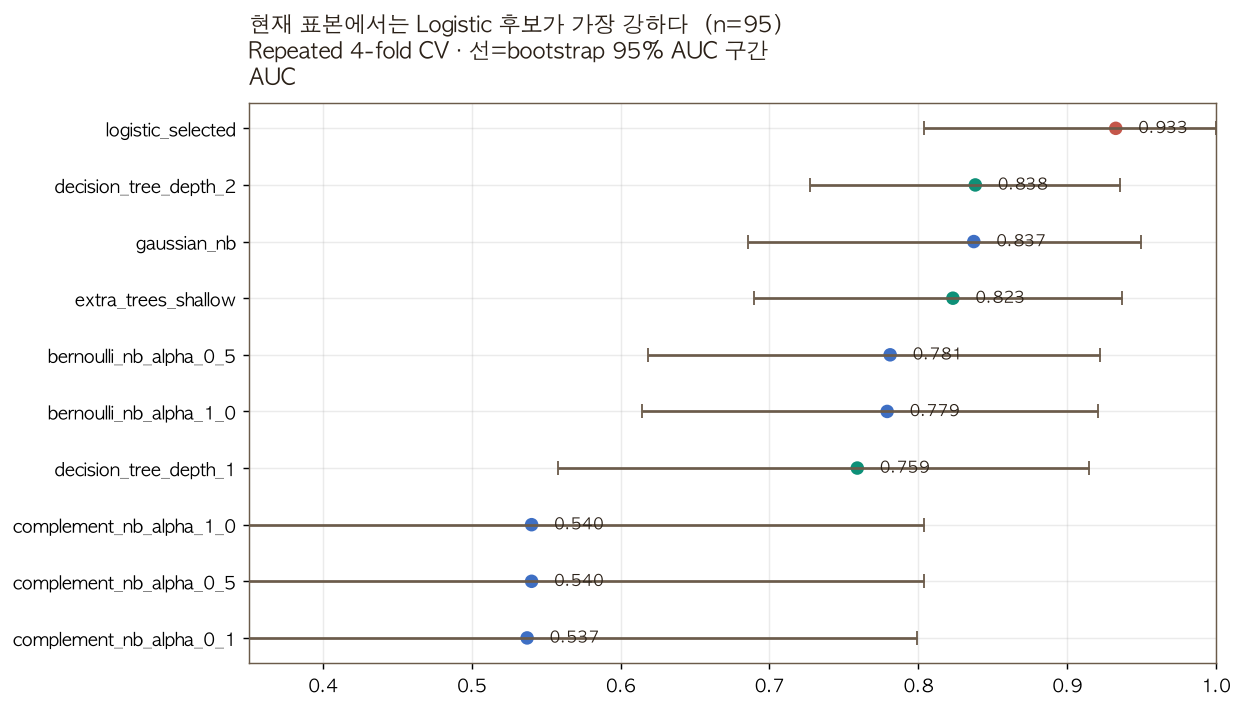

In [4]:
plot = metrics.sort_values('auc')
fig, ax = R.new(
    '현재 표본에서는 Logistic 후보가 가장 강하다',
    len(d),
    sub='Repeated 4-fold CV · 선=bootstrap 95% AUC 구간',
    ylab='AUC',
    figsize=(9.6, 5.6),
)
ypos = np.arange(len(plot))
colors = plot.family.map({'logistic': R.PALETTE[0], 'naive_bayes': R.PALETTE[1], 'rule_tree': R.PALETTE[2]}).tolist()
ax.errorbar(
    plot.auc,
    ypos,
    xerr=[plot.auc - plot.auc_ci_low, plot.auc_ci_high - plot.auc],
    fmt='none',
    ecolor=R.MUTED,
    capsize=4,
)
ax.scatter(plot.auc, ypos, c=colors, s=42)
ax.set_yticks(ypos, plot.model)
ax.set_xlim(0.35, 1.0)
for i, row in enumerate(plot.itertuples()):
    ax.text(min(row.auc + 0.015, 0.98), i, f'{row.auc:.3f}', va='center', fontsize=9)
chart_auc = R.save(fig, ax, 'g5_model_family_auc', zero_base=False)
print(R.check(chart_auc))
display(R.show(chart_auc))


## 3. Precision/Recall 관점

유도 로직으로 쓰려면 AUC만 높아서는 안 된다. 상위 30%를 표시했을 때 양성을 얼마나 잡는지 같이 본다.

g5_model_family_pr_precision.png  1228x711px


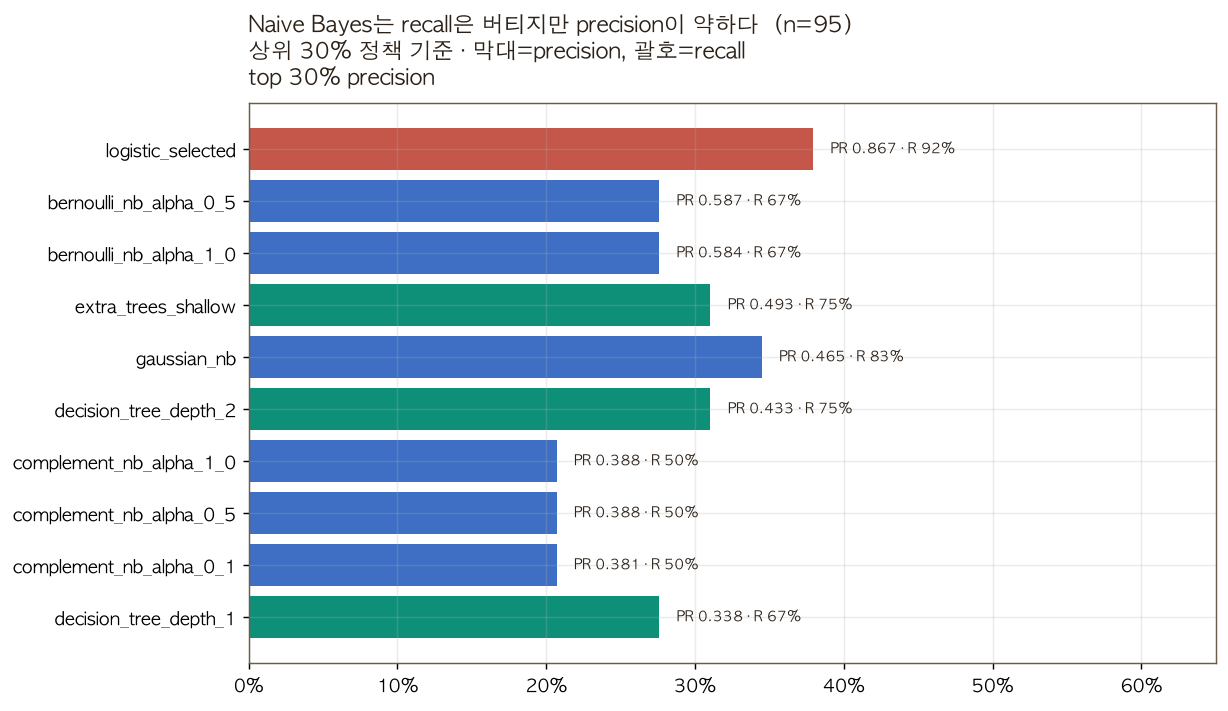

In [5]:
plot_pr = metrics.sort_values('pr_auc')
fig, ax = R.new(
    'Naive Bayes는 recall은 버티지만 precision이 약하다',
    len(d),
    sub='상위 30% 정책 기준 · 막대=precision, 괄호=recall',
    ylab='top 30% precision',
    figsize=(9.6, 5.6),
)
colors = plot_pr.family.map({'logistic': R.PALETTE[0], 'naive_bayes': R.PALETTE[1], 'rule_tree': R.PALETTE[2]}).tolist()
ax.barh(np.arange(len(plot_pr)), plot_pr.top30_precision, color=colors)
ax.set_yticks(np.arange(len(plot_pr)), plot_pr.model)
ax.set_xlim(0.0, 0.65)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, row in enumerate(plot_pr.itertuples()):
    ax.text(row.top30_precision + 0.012, i, f'PR {row.pr_auc:.3f} · R {row.top30_recall:.0%}', va='center', fontsize=8)
chart_pr = R.save(fig, ax, 'g5_model_family_pr_precision', zero_base=False)
print(R.check(chart_pr))
display(R.show(chart_pr))


## 4. 얕은 Tree가 알려주는 규칙

Tree는 주 모델이라기보다 설명 도구다. depth 2 tree가 어떤 분기를 고르는지만 본다.

In [6]:
tree = fitted['decision_tree_depth_2'].named_steps['clf']
tree_text = export_text(tree, feature_names=tree_features, decimals=3)
(OUT / 'decision_tree_depth_2_rules.txt').write_text(tree_text, encoding='utf-8')
print(tree_text)

importance = pd.DataFrame({
    'feature': tree_features,
    'importance': tree.feature_importances_,
}).sort_values('importance', ascending=False)
importance.to_csv(OUT / 'decision_tree_depth_2_importance.csv', index=False)
display(importance.head(12))


|--- log_early_entry_auth_events <= 0.896
|   |--- log_early_ga_auto_events <= 1.701
|   |   |--- class: 0
|   |--- log_early_ga_auto_events >  1.701
|   |   |--- class: 0
|--- log_early_entry_auth_events >  0.896
|   |--- log_early_zone_enter_events <= 0.347
|   |   |--- class: 0
|   |--- log_early_zone_enter_events >  0.347
|   |   |--- class: 1



,feature,importance
7,log_early_entry_auth_events,0.720573
28,log_early_zone_enter_events,0.228932
6,log_early_ga_auto_events,0.050495
0,log_early_tracked_events,0.000000
24,log_early_churn_score_events,0.000000
19,log_early_chop_tree_events,0.000000
20,log_early_mine_ore_events,0.000000
21,log_early_npc_talk_events,0.000000
22,log_early_tutorial_step_events,0.000000
23,log_early_quest_offered_events,0.000000


g5_model_family_tree_importance.png  1163x631px


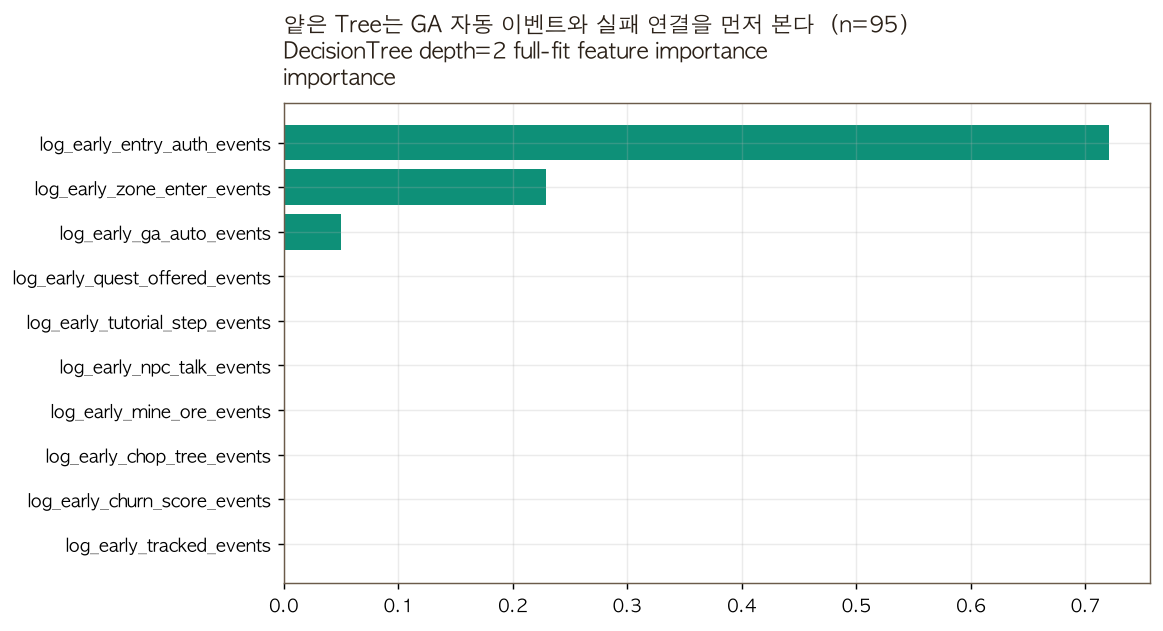

In [7]:
imp = importance.head(10).sort_values('importance')
fig, ax = R.new(
    '얕은 Tree는 GA 자동 이벤트와 실패 연결을 먼저 본다',
    len(d),
    sub='DecisionTree depth=2 full-fit feature importance',
    ylab='importance',
    figsize=(8.6, 4.8),
)
ax.barh(np.arange(len(imp)), imp.importance, color=R.PALETTE[2])
ax.set_yticks(np.arange(len(imp)), imp.feature)
chart_tree = R.save(fig, ax, 'g5_model_family_tree_importance', zero_base=True)
print(R.check(chart_tree))
display(R.show(chart_tree))


## 5. 판정

Logistic 후보를 주 모델로 유지한다. ComplementNB는 이벤트 카운트형 baseline으로 보조 가치가 있지만 대체 후보는 아니다. depth 1/2 Tree와 shallow ExtraTrees는 규칙 설명에는 도움이 되지만, 성능 기준으로 주 모델이 되기에는 약하다.

**이 숫자로 말할 수 없는 것:** 표본 95대, 양성 12대다. Naive Bayes와 Tree가 낮게 나온 것이 영구 기각은 아니다. 신규 데이터가 쌓이면 event vocabulary가 안정되면서 결과가 바뀔 수 있다. XGBoost/LightGBM은 이번 결과표에 없는 것이 정상이다. 지금 넣으면 과적합을 모델 성능으로 착각할 가능성이 크다.

**다음에 확인할 것:** 며칠 뒤 같은 feature SQL로 표본을 늘린 뒤, Logistic 후보와 ComplementNB baseline만 먼저 재검증한다. 양성이 30대 이상이 되면 그때 shallow LightGBM/XGBoost를 “보조 비교”로 열 수 있다.

In [8]:
best = metrics.iloc[0].to_dict()
logistic = metrics.loc[metrics.model.eq('logistic_selected')].iloc[0].to_dict()
nb_best = metrics.loc[metrics.family.eq('naive_bayes')].iloc[0].to_dict()
tree_best = metrics.loc[metrics.family.eq('rule_tree')].iloc[0].to_dict()

summary = {
    'date': '2026-09-15',
    'verdict': 'logistic_selected 유지; ComplementNB는 보조 baseline; Tree는 규칙 설명용',
    'sample': {'devices': int(len(d)), 'positives': int(y.sum()), 'positive_rate': float(y.mean())},
    'target': 'later_active: 10m-24h deliberate action',
    'excluded': 'GA4 ab_variant beta_A/beta_B marked devices',
    'not_used': ['A/B variant effect', 'later_* as features', 'raw identifiers', 'XGBoost/LightGBM'],
    'best_overall': best,
    'logistic_selected': logistic,
    'best_naive_bayes': nb_best,
    'best_rule_tree': tree_best,
    'criteria': {
        'alternative_requires_auc_or_pr_auc_above_logistic': True,
        'alternative_requires_top30_recall_gte_80pct': True,
        'support_model_allowed_when_interpretable': True,
    },
}
with open(OUT / 'model_family_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

score_df = d[['device_label', 'split_segment', 'channel_segment', 'early_tracked_events', 'early_actions', 'deliberate_share', 'later_active']].copy()
for name, p in preds.items():
    score_df[name] = p
score_df.to_csv(OUT / 'model_family_scores.csv', index=False)

print(json.dumps(summary, ensure_ascii=False, indent=2)[:2600])


{
  "date": "2026-09-15",
  "verdict": "logistic_selected 유지; ComplementNB는 보조 baseline; Tree는 규칙 설명용",
  "sample": {
    "devices": 95,
    "positives": 12,
    "positive_rate": 0.12631578947368421
  },
  "target": "later_active: 10m-24h deliberate action",
  "excluded": "GA4 ab_variant beta_A/beta_B marked devices",
  "not_used": [
    "A/B variant effect",
    "later_* as features",
    "raw identifiers",
    "XGBoost/LightGBM"
  ],
  "best_overall": {
    "model": "logistic_selected",
    "family": "logistic",
    "n_features": 29,
    "auc": 0.9327309236947791,
    "pr_auc": 0.8667540792540794,
    "top30_cutoff": 0.23325880234865076,
    "top30_flagged": 29,
    "top30_precision": 0.3793103448275862,
    "top30_recall": 0.9166666666666666,
    "top30_balanced_acc": 0.8498995983935742,
    "auc_ci_low": 0.8040044402802673,
    "auc_ci_high": 1.0,
    "pr_auc_ci_low": 0.6709821428571429,
    "pr_auc_ci_high": 1.0
  },
  "logistic_selected": {
    "model": "logistic_selected",
    "